# Ejercicio de Regresión Lineal con California Housing

A continuación tienes un ejemplo completo, ideal para aprender en Jupyter Notebook. Cada línea tiene comentarios claros para que entiendas el proceso. El código carga el dataset **California Housing**, realiza regresión lineal, y evalúa la calidad del modelo.

## Paso 1: Importar librerías esenciales

Necesitamos las siguientes librerías para todo el proceso:
- **pandas**: Para manipulación y análisis de datos
- **numpy**: Para operaciones matemáticas
- **matplotlib**: Para gráficos
- **sklearn**: Para machine learning (modelos, métricas, escalado)

In [1]:
# 1. Importar librerías esenciales
import pandas as pd        # Para manipulación y análisis de datos
import numpy as np         # Para operaciones matemáticas
import matplotlib.pyplot as plt  # Para gráficos
from sklearn.datasets import fetch_california_housing  # Cargar dataset real
from sklearn.model_selection import train_test_split    # Para separar datos
from sklearn.linear_model import LinearRegression      # Modelo de regresión lineal
from sklearn.metrics import mean_squared_error, r2_score # Métricas de evaluación
from sklearn.preprocessing import StandardScaler        # Escalado de características

## Paso 2: Cargar el dataset California Housing

El dataset se descarga automáticamente. Contiene información sobre precios de viviendas en California con variables como:
- **MedInc**: Ingreso medio de la zona
- **HouseAge**: Antiguedad de la casa
- **AveRooms**: Promedio de habitaciones
- **MedHouseVal**: Precio medio de la casa (nuestra variable objetivo)

In [2]:
# 2. Cargar el dataset California Housing
# El dataset se descarga automáticamente y devuelve un DataFrame listo para usar
california = fetch_california_housing(as_frame=True) 
df = california.frame      # Almacenamos el DataFrame en la variable 'df'

# Visualizamos las primeras filas para entender los datos
print("Primeras filas del dataset:")
print(df.head())           # Muestra cinco filas y sus variables
print("\nForma del dataset:", df.shape)

Primeras filas del dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Forma del dataset: (20640, 9)


## Paso 3: Explorar el dataset

Veamos información general sobre los datos:

In [3]:
# Información general
print("Información del dataset:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Estadísticas descriptivas:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499

## Paso 4: Elegir variables (Features y Target)

Separamos:
- **X**: Las características (variables independientes) - todas menos el precio
- **y**: El objetivo (variable dependiente) - precio medio de la casa

In [4]:
# 3. Elegir variables
# X contiene las características (sin el precio), y contiene el objetivo (precio medio de la casa)
X = df.drop('MedHouseVal', axis=1)  # Todos menos la variable objetivo
y = df['MedHouseVal']               # Variable objetivo: precio medio de la vivienda

print(f"Características (X): {X.shape}")
print(f"Objetivo (y): {y.shape}")

Características (X): (20640, 8)
Objetivo (y): (20640,)


## Paso 5: Separar en conjunto de entrenamiento y test

Dividimos los datos:
- **80%** para entrenar el modelo
- **20%** para evaluar el modelo

Esto nos ayuda a ver si el modelo generaliza bien a datos nuevos.

In [5]:
# 4. Separar en conjunto de entrenamiento y test
# train_test_split separa aleatoriamente un 80% para entrenamiento y 20% para test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]} muestras")
print(f"Datos de test: {X_test.shape[0]} muestras")

Datos de entrenamiento: 16512 muestras
Datos de test: 4128 muestras


## Paso 6: Escalar datos

El escalado es importante porque:
- Las características tienen rangos muy diferentes
- Evita que variables grandes dominen el modelo
- Mejora la convergencia del algoritmo

**Importante**: Se ajusta el escalador solo con datos de entrenamiento y se aplica igual al test.

In [6]:
# 5. Escalar datos para mejorar la eficacia de la regresión
# Evita que variables con distinto rango influyan desproporcionadamente
scaler = StandardScaler()           # Creamos el objeto escalador
X_train_scaled = scaler.fit_transform(X_train) # Ajustamos y transformamos entrenamiento
X_test_scaled = scaler.transform(X_test)       # Transformamos test usando el mismo escalado

print("Media de características escaladas (entrenamiento):", X_train_scaled.mean(axis=0).round(3))
print("Desv. est. de características escaladas (entrenamiento):", X_train_scaled.std(axis=0).round(3))

Media de características escaladas (entrenamiento): [-0. -0.  0. -0.  0.  0.  0.  0.]
Desv. est. de características escaladas (entrenamiento): [1. 1. 1. 1. 1. 1. 1. 1.]


## Paso 7: Crear y entrenar el modelo

Usamos **regresión lineal** que encuentra la mejor línea/plano que describe la relación entre características y precio.

In [7]:
# 6. Crear y entrenar el modelo de regresión lineal
model = LinearRegression()          # Creamos el modelo
model.fit(X_train_scaled, y_train)  # Entrenamos con el conjunto de entrenamiento

print("Modelo entrenado exitosamente")

Modelo entrenado exitosamente


## Paso 8: Examinar los coeficientes del modelo

Los coeficientes nos dicen:
- **Intercepto**: El valor base cuando todas las características son 0
- **Coeficientes**: El impacto de cada característica en el precio

In [8]:
# 7. Evaluar los coeficientes del modelo
print("Intercepto:", model.intercept_.round(4))    # Valor de b_0 (ordenada al origen)
print("\nCoeficientes por característica:")
for nombre, coef in zip(X.columns, model.coef_):
    print(f"  {nombre:15} : {coef:.6f}")

Intercepto: 2.0719

Coeficientes por característica:
  MedInc          : 0.854383
  HouseAge        : 0.122546
  AveRooms        : -0.294410
  AveBedrms       : 0.339259
  Population      : -0.002308
  AveOccup        : -0.040829
  Latitude        : -0.896929
  Longitude       : -0.869842


## Paso 9: Hacer predicciones

Usamos el modelo entrenado para predecir precios en el conjunto de test.

In [9]:
# 8. Hacer predicciones con el conjunto de test
y_pred = model.predict(X_test_scaled)     # Predice precios de casas en el test

print(f"Primeras 10 predicciones: {y_pred[:10].round(3)}")
print(f"Primeros 10 valores reales: {y_test.iloc[:10].values.round(3)}")

Primeras 10 predicciones: [0.719 1.764 2.71  2.839 2.605 2.012 2.646 2.169 2.741 3.916]
Primeros 10 valores reales: [0.477 0.458 5.    2.186 2.78  1.587 1.982 1.575 3.4   4.466]


## Paso 10: Evaluar la calidad del modelo

Calculamos métricas para saber qué tan bien predice el modelo:
- **MSE** (Mean Squared Error): Error cuadrático medio - penaliza errores grandes
- **RMSE** (Root Mean Squared Error): Raíz del error cuadrático - misma unidad que el precio
- **R²** (Coeficiente de Determinación): Proporción de varianza explicada por el modelo (0-1)

In [10]:
# 9. Calcular métricas para saber la calidad del modelo
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Métricas de evaluación:")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²:   {r2:.4f}")
print(f"\nInterpretación: El modelo explica el {r2*100:.2f}% de la varianza en los precios")

Métricas de evaluación:
  MSE:  0.5559
  RMSE: 0.7456
  R²:   0.5758

Interpretación: El modelo explica el 57.58% de la varianza en los precios


## Paso 11: Visualizar resultados

Graficamos los precios reales vs predichos. Si el modelo funciona bien, los puntos deberían estar cerca de la línea diagonal.

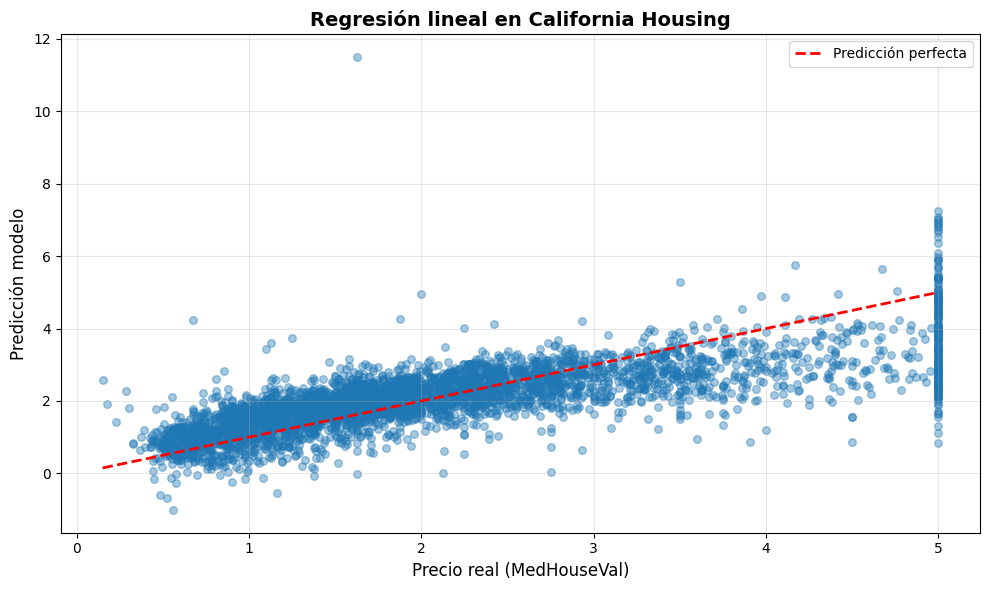

In [11]:
# 10. Visualizar resultados: ¿el modelo predice bien?
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, s=30)           # Grafica precios reales vs predichos
plt.xlabel("Precio real (MedHouseVal)", fontsize=12)    # Etiqueta eje X
plt.ylabel("Predicción modelo", fontsize=12)            # Etiqueta eje Y
plt.title("Regresión lineal en California Housing", fontsize=14, fontweight='bold') # Título
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Predicción perfecta') # Línea ideal
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()                                       # Muestra la figura

## Paso 12: Análisis de residuos

Los residuos son las diferencias entre predicciones y valores reales. Un buen modelo tiene residuos pequeños y aleatorios.

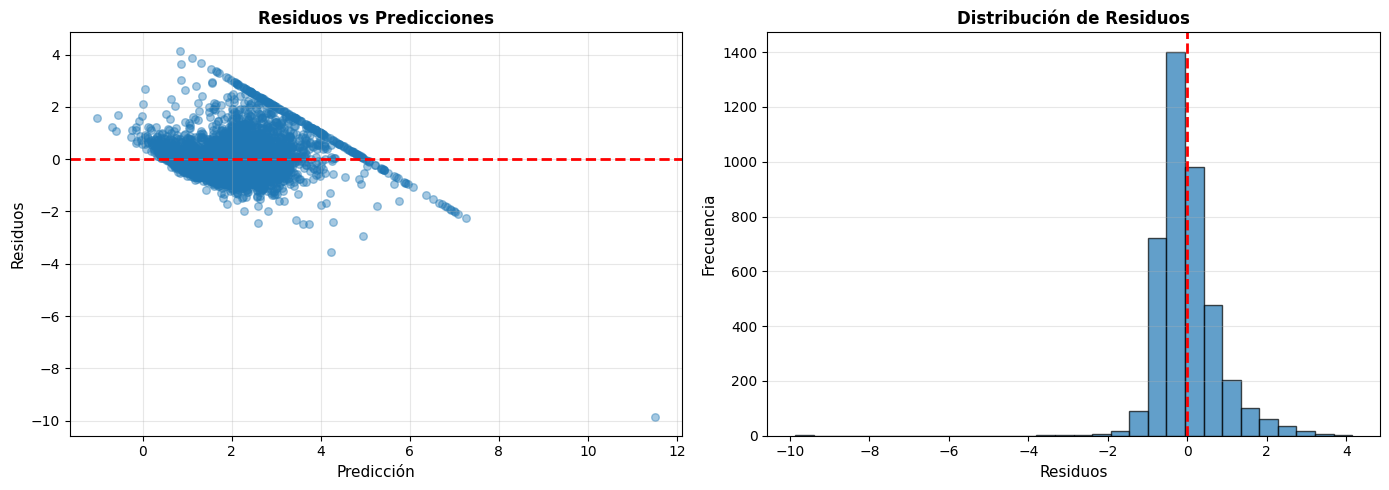

Estadísticas de residuos:
  Media: 0.003479
  Desv. Est: 0.7457
  Min: -9.8753
  Max: 4.1484


In [12]:
# Calcular residuos
residuos = y_test - y_pred

# Visualizar residuos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Residuos vs predicciones
axes[0].scatter(y_pred, residuos, alpha=0.4, s=30)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicción', fontsize=11)
axes[0].set_ylabel('Residuos', fontsize=11)
axes[0].set_title('Residuos vs Predicciones', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Histograma de residuos
axes[1].hist(residuos, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuos', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución de Residuos', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Estadísticas de residuos:")
print(f"  Media: {residuos.mean():.6f}")
print(f"  Desv. Est: {residuos.std():.4f}")
print(f"  Min: {residuos.min():.4f}")
print(f"  Max: {residuos.max():.4f}")

## Paso 13: Conclusiones del Modelo

Ahora vamos a generar un análisis integral que nos ayude a entender si el modelo funciona bien o mal, considerando todas las métricas calculadas.

In [13]:
# Análisis integral del rendimiento del modelo
print("=" * 70)
print("ANÁLISIS DE CONCLUSIONES DEL MODELO DE REGRESIÓN LINEAL")
print("=" * 70)

# 1. Evaluar R²
print("\n1️⃣  CAPACIDAD PREDICTIVA (R²):")
print(f"   R² = {r2:.4f}")
if r2 >= 0.8:
    print("   ✅ EXCELENTE: El modelo explica más del 80% de la varianza")
elif r2 >= 0.6:
    print("   ✅ BUENO: El modelo explica entre 60-80% de la varianza")
elif r2 >= 0.4:
    print("   ⚠️  ACEPTABLE: El modelo explica entre 40-60% de la varianza")
else:
    print("   ❌ POBRE: El modelo explica menos del 40% de la varianza")

# 2. Evaluar RMSE
print(f"\n2️⃣  ERROR PROMEDIO (RMSE):")
print(f"   RMSE = ${rmse:.4f} (en cientos de miles de dólares)")
precio_medio = y_test.mean()
error_porcentaje = (rmse / precio_medio) * 100
print(f"   Precio medio en test: ${precio_medio:.4f}")
print(f"   Error promedio: {error_porcentaje:.2f}% del precio medio")
if error_porcentaje <= 15:
    print("   ✅ BUENO: El error está por debajo del 15% del precio medio")
elif error_porcentaje <= 25:
    print("   ⚠️  ACEPTABLE: El error está entre 15-25% del precio medio")
else:
    print("   ❌ ALTO: El error supera el 25% del precio medio")

# 3. Analizar residuos
print(f"\n3️⃣  DISTRIBUCIÓN DE RESIDUOS:")
print(f"   Media de residuos: {residuos.mean():.6f}")
if abs(residuos.mean()) < 0.001:
    print("   ✅ BIEN: La media es casi cero (no hay sesgo sistemático)")
else:
    print("   ⚠️  Hay ligero sesgo sistemático en las predicciones")

print(f"   Desv. Est. de residuos: {residuos.std():.4f}")
print(f"   Rango de residuos: [{residuos.min():.4f}, {residuos.max():.4f}]")

# 4. Análisis de precisión por rango de precios
print(f"\n4️⃣  ANÁLISIS POR RANGO DE PRECIOS:")
quartiles = y_test.quantile([0.25, 0.5, 0.75])
bajo = y_test[y_test <= quartiles[0.25]]
medio_bajo = y_test[(y_test > quartiles[0.25]) & (y_test <= quartiles[0.5])]
medio_alto = y_test[(y_test > quartiles[0.5]) & (y_test <= quartiles[0.75])]
alto = y_test[y_test > quartiles[0.75]]

if len(bajo) > 0:
    error_bajo = np.sqrt(mean_squared_error(bajo, y_pred[y_test.isin(bajo)]))
    print(f"   Casas baratas (Q1): RMSE = ${error_bajo:.4f}")

if len(medio_bajo) > 0:
    error_medio_bajo = np.sqrt(mean_squared_error(medio_bajo, y_pred[y_test.isin(medio_bajo)]))
    print(f"   Casas medio-bajas (Q2): RMSE = ${error_medio_bajo:.4f}")

if len(medio_alto) > 0:
    error_medio_alto = np.sqrt(mean_squared_error(medio_alto, y_pred[y_test.isin(medio_alto)]))
    print(f"   Casas medio-altas (Q3): RMSE = ${error_medio_alto:.4f}")

if len(alto) > 0:
    error_alto = np.sqrt(mean_squared_error(alto, y_pred[y_test.isin(alto)]))
    print(f"   Casas caras (Q4): RMSE = ${error_alto:.4f}")

# 5. Conclusión final
print("\n" + "=" * 70)
print("CONCLUSIÓN GENERAL:")
print("=" * 70)

if r2 >= 0.7 and error_porcentaje <= 20:
    print("✅ MODELO BUENO: El modelo tiene un desempeño satisfactorio.")
    print("   Puede usarse para predicciones con una precisión razonable.")
elif r2 >= 0.5 and error_porcentaje <= 30:
    print("⚠️  MODELO ACEPTABLE: El modelo funciona pero tiene limitaciones.")
    print("   Consideraría hacer mejoras (features adicionales, otro modelo).")
else:
    print("❌ MODELO MEJORABLE: El modelo no predice suficientemente bien.")
    print("   Se recomienda explorar:")
    print("   - Regresión polinomial o modelos no lineales")
    print("   - Más características o feature engineering")
    print("   - Otros algoritmos (Random Forest, Gradient Boosting, etc.)")

print("\nRecuerda: La regresión lineal asume relaciones lineales entre")
print("variables. Si esa suposición no se cumple, otros modelos pueden")
print("ser más apropiados.")
print("=" * 70)

ANÁLISIS DE CONCLUSIONES DEL MODELO DE REGRESIÓN LINEAL

1️⃣  CAPACIDAD PREDICTIVA (R²):
   R² = 0.5758
   ⚠️  ACEPTABLE: El modelo explica entre 40-60% de la varianza

2️⃣  ERROR PROMEDIO (RMSE):
   RMSE = $0.7456 (en cientos de miles de dólares)
   Precio medio en test: $2.0550
   Error promedio: 36.28% del precio medio
   ❌ ALTO: El error supera el 25% del precio medio

3️⃣  DISTRIBUCIÓN DE RESIDUOS:
   Media de residuos: 0.003479
   ⚠️  Hay ligero sesgo sistemático en las predicciones
   Desv. Est. de residuos: 0.7457
   Rango de residuos: [-9.8753, 4.1484]

4️⃣  ANÁLISIS POR RANGO DE PRECIOS:
   Casas baratas (Q1): RMSE = $0.5734
   Casas medio-bajas (Q2): RMSE = $0.6120
   Casas medio-altas (Q3): RMSE = $0.4650
   Casas caras (Q4): RMSE = $1.1419

CONCLUSIÓN GENERAL:
❌ MODELO MEJORABLE: El modelo no predice suficientemente bien.
   Se recomienda explorar:
   - Regresión polinomial o modelos no lineales
   - Más características o feature engineering
   - Otros algoritmos (Random F

## Resumen del proceso completo

1. ✅ **Importamos** las librerías necesarias
2. ✅ **Cargamos** el dataset California Housing
3. ✅ **Exploramos** los datos (forma, tipos, estadísticas)
4. ✅ **Separamos** features (X) y target (y)
5. ✅ **Dividimos** en entrenamiento (80%) y test (20%)
6. ✅ **Escalamos** las características para mejorar el modelo
7. ✅ **Entrenamos** un modelo de regresión lineal
8. ✅ **Examinamos** los coeficientes del modelo
9. ✅ **Hacemos** predicciones en el conjunto de test
10. ✅ **Evaluamos** la calidad con MSE, RMSE y R²
11. ✅ **Visualizamos** predicciones vs valores reales
12. ✅ **Analizamos** residuos para detectar problemas

## Próximos pasos posibles

- 🔍 Probar **regresión polinomial** para capturar relaciones no lineales
- 🎯 Usar **validación cruzada** para una evaluación más robusta
- 📊 Experimentar con **regularización** (Ridge, Lasso) para evitar sobreajuste
- 🔧 Hacer **feature engineering** para mejorar el modelo
- 📈 Comparar con otros modelos (**árboles de decisión**, **random forest**, etc.)